In [1]:
from qiskit import QuantumCircuit, transpile
# from qiskit.providers.basic_provider import BasicProvider
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import qasm2

In [2]:
epr_circuit = QuantumCircuit(2, 2)
epr_circuit.h(0)
epr_circuit.cx(0, 1)
epr_circuit.measure([0, 1], [0, 1])

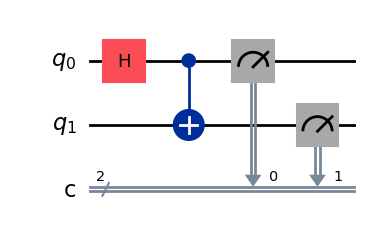

In [3]:
epr_circuit.draw("mpl")

In [4]:
print(qasm2.dumps(epr_circuit))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];


In [9]:
singlet_circuit = QuantumCircuit(2, 2)
singlet_circuit.h(0)
singlet_circuit.x(1)
singlet_circuit.cx(0, 1)
singlet_circuit.measure([0, 1], [0, 1])

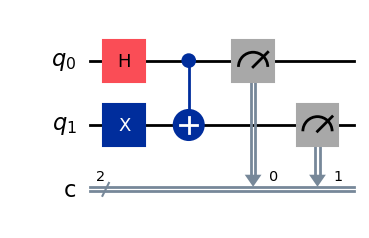

In [10]:
singlet_circuit.draw("mpl")

In [12]:
print(qasm2.dumps(singlet_circuit))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
x q[1];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];


In [13]:
ghz_circuit = QuantumCircuit(3, 3)
ghz_circuit.h(0)
ghz_circuit.cx([0, 0], [1, 2])
ghz_circuit.measure([0, 1, 2], [0, 1, 2])

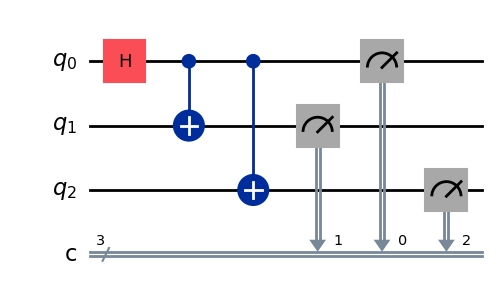

In [14]:
ghz_circuit.draw("mpl")

In [16]:
print(qasm2.dumps(ghz_circuit))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h q[0];
cx q[0],q[1];
cx q[0],q[2];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];


In [17]:
# simulator = BasicProvider().get_backend('basic_simulator')
simulator = AerSimulator()

In [18]:
compiled_epr_circuit = transpile(epr_circuit, simulator)
epr_circuit_job = simulator.run(compiled_epr_circuit, shots=1024)
epr_circuit_simulation_result = epr_circuit_job.result()
epr_circuit_simulation_result.get_counts()

{'11': 505, '00': 519}

In [19]:
epr_circuit_simulation_result

Result(backend_name='aer_simulator', backend_version='0.17.1', job_id='060e3e06-784d-428b-b8d2-c84b9c82482d', success=True, results=[ExperimentResult(shots=1024, success=True, meas_level=2, data=ExperimentResultData(counts={'0x3': 505, '0x0': 519}), header={'creg_sizes': [['c', 2]], 'global_phase': 0.0, 'memory_slots': 2, 'n_qubits': 2, 'name': 'circuit-171', 'qreg_sizes': [['q', 2]], 'metadata': {}}, status=DONE, seed_simulator=699046860, metadata={'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0073527, 'sample_measure_time': 0.0005676, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 65136, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 32, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}, time_taken=0.0073527)], date=2025-07-28T17:10:04.485

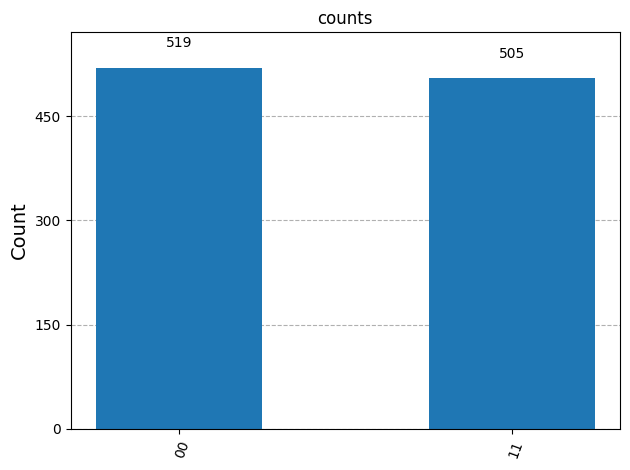

In [20]:
plot_histogram(epr_circuit_simulation_result.get_counts(), title='counts')

In [21]:
compiled_singlet_circuit = transpile(singlet_circuit, simulator)
singlet_circuit_job = simulator.run(compiled_singlet_circuit, shot=1024)
singlet_circuit_results = singlet_circuit_job.result()

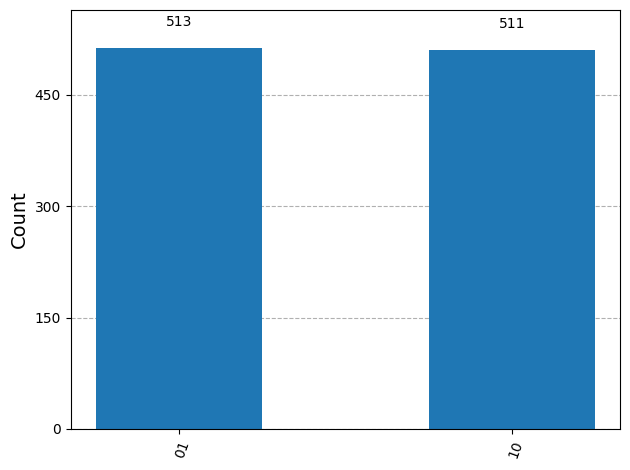

In [22]:
plot_histogram(singlet_circuit_results.get_counts())

In [23]:
compiled_ghz_circuit = transpile(ghz_circuit, simulator)
ghz_circuit_job = simulator.run(compiled_ghz_circuit, shot=1024)
ghz_circuit_results = ghz_circuit_job.result()

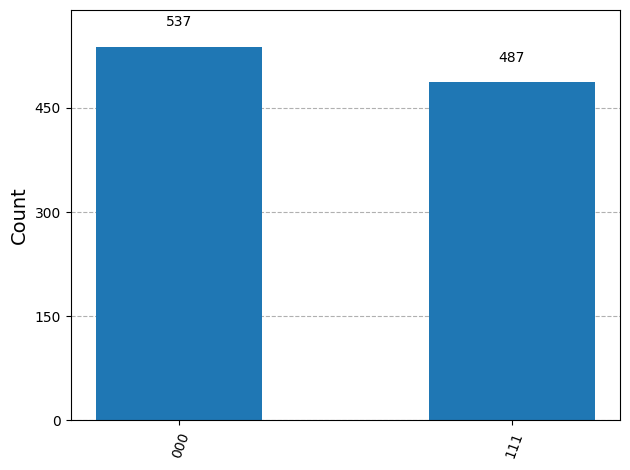

In [24]:
plot_histogram(ghz_circuit_results.get_counts())